In [1]:
#数据准备
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

# 内存：390MB，可逐块读取或直接全部加载，确保有足够内存）
df = pd.read_csv("../data/btcusd_1-min_data.csv")

# 转换时间戳
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df.set_index('Timestamp', inplace=True)
df.sort_index(inplace=True)

# 查看数据范围
print(f"数据时间范围：{df.index.min()} 至 {df.index.max()}")
print(f"总行数：{len(df)}")

数据时间范围：2012-01-01 10:01:00 至 2026-01-26 23:59:00
总行数：7399839


In [2]:
#分钟级收益率计算
df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))

#日度已实现波动率（RV）
# 按日重采样，计算每天有多少分钟数据
daily_counts = df['log_ret'].resample('D').count()

# 计算每日 RV（方差）
daily_rv = df['log_ret'].resample('D').apply(lambda x: np.sum(x**2))

# 设置阈值：如果某天分钟数少于1000（约70%），认为该天数据不可靠，设为NaN
min_obs = 1000
daily_rv[daily_counts < min_obs] = np.nan

# 计算日收益率（基于每日最后收盘价）
daily_close = df['Close'].resample('D').last()
daily_ret = np.log(daily_close / daily_close.shift(1))

# 合并为日度数据
data = pd.concat([daily_ret, daily_rv], axis=1, keys=['ret', 'rv'])
data.dropna(inplace=True)  # 去除RV缺失的天（包括首日收益率NaN）

print(f"有效日度数据量：{len(data)}")
print(data.head())

有效日度数据量：5138
                 ret        rv
Timestamp                     
2012-01-02  0.032523  0.001058
2012-01-03  0.056380  0.007253
2012-01-04  0.051577  0.009645
2012-01-05  0.142023  0.003875
2012-01-06 -0.003120  0.003701


In [3]:
#划分训练集和测试集
train_size = int(len(data) * 0.8)
train = data.iloc[:train_size]
test = data.iloc[train_size:]

print(f"训练集：{train.index[0]} 至 {train.index[-1]}，共 {len(train)} 天")
print(f"测试集：{test.index[0]} 至 {test.index[-1]}，共 {len(test)} 天")

#adf检验
result = adfuller(train['ret'].dropna())
print(f'ADF p-value: {result[1]:.6f}')
if result[1] < 0.05:
    print("收益率序列平稳")
else:
    print("收益率序列非平稳，请检查")

训练集：2012-01-02 00:00:00 至 2023-04-03 00:00:00，共 4110 天
测试集：2023-04-04 00:00:00 至 2026-01-26 00:00:00，共 1028 天
ADF p-value: 0.000000
收益率序列平稳


In [4]:
#1.garch模型
#可调参数：
#阶数 (p, q)：标准 GARCH(1,1) 使用 p=1, q=1，理论上可以尝试其他阶数（如 p=2, q=1）
#均值方程设定：可以选择是否包含常数项（mean='Constant'）或设定为零均值（mean='Zero'）。
#残差分布假设：默认正态分布，也可选择studen's t 分布或广义误差分布（GED）以更好地拟合尖峰厚尾特征。
#窗口长度：滚动窗口或者固定窗口/测试集和训练集的划分

# 将收益率乘以100，便于模型收敛
all_ret_scaled = data['ret'] * 100
train_len = len(train)

garch_pred = []
garch_params = []  # 可选：保存每次估计的参数

for i in range(len(test)):
    end_idx = train_len + i  # 当前测试点前一天的索引（包含前一天）
    train_temp = all_ret_scaled.iloc[:end_idx]  # 使用截至前一天的所有数据
    if len(train_temp) < 10:
        continue
    model = arch_model(train_temp, mean='Constant', vol='GARCH', p=1, q=1, dist='normal')
    res = model.fit(update_freq=5, disp='off')
    garch_params.append(res.params)
    fore = res.forecast(horizon=1)
    pred_var_scaled = fore.variance.iloc[-1].iloc[0]  # 缩放后的方差
    pred_var = pred_var_scaled / 10000  # 还原为原始尺度（除以100^2）
    garch_pred.append(pred_var)

# 索引对齐（可能因起始数据不足而少于测试集长度）
garch_pred = pd.Series(garch_pred, index=test.index[:len(garch_pred)])

# 查看参数平均值（可选）
if garch_params:
    avg_params = pd.DataFrame(garch_params).mean()
    print("平均参数估计：")
    print(avg_params)
    


平均参数估计：
mu          0.132644
omega       0.605255
alpha[1]    0.153347
beta[1]     0.817840
dtype: float64


In [5]:
#2.EWMA模型
#调整参数：
#衰减因子 λ：λ ∈ (0,1)，控制历史信息的衰减速度。λ越大，历史权重衰减越慢，波动率估计越平滑；λ 越小，对近期收益越敏感，波动率更新越快。
#常用经验值 0.94（日数据，RiskMetrics 推荐）或 0.97（更平滑）。也可以基于训练集，通过最小化样本内预测误差（如 MSE）来优化 λ。方法：在训练集上滚动计算 EWMA 预测，并与真实 RV 比较，选择使 MSE 最小的 λ。
#初始方差设定：起始点的方差估计方法（如样本方差、首个收益平方等）会影响初期预测，但随着时间推移影响会衰减。


lambda_ = 0.94

ret_train = train['ret'].values  # 原始尺度

# 初始化方差序列
sigma2_train = np.zeros(len(ret_train))
initial_window = min(30, len(ret_train))
sigma2_train[0] = np.var(ret_train[:initial_window])  # 或使用第一个收益率的平方

for t in range(1, len(ret_train)):
    sigma2_train[t] = lambda_ * sigma2_train[t-1] + (1 - lambda_) * ret_train[t-1]**2
    
ewma_pred = []
last_sigma2 = sigma2_train[-1]
all_ret_orig = data['ret'].values  # 原始尺度

for i in range(len(test)):
    t = train_len + i
    if i == 0:
        sigma_t = last_sigma2
    else:
        sigma_t = lambda_ * sigma_t + (1 - lambda_) * all_ret_orig[t-1]**2
    ewma_pred.append(sigma_t)

ewma_pred = pd.Series(ewma_pred, index=test.index)

In [6]:
#两个模型对比
# 对齐真实值（确保索引一致）
true_rv = test['rv'].loc[ewma_pred.index]          # 以EWMA索引为准
garch_pred_aligned = garch_pred.loc[true_rv.index] # 取共同部分

def compute_metrics(true, pred):
    mse = np.mean((pred - true)**2)
    mae = np.mean(np.abs(pred - true))
    # QLIKE: mean( true/pred - log(true/pred) - 1 )
    if (pred <= 0).any():
        print("警告：预测值非正，QLIKE可能无效")
        qlike = np.nan
    else:
        qlike = np.mean(true / pred - np.log(true / pred) - 1)
    return mse, mae, qlike

mse_g, mae_g, qlike_g = compute_metrics(true_rv, garch_pred_aligned)
mse_e, mae_e, qlike_e = compute_metrics(true_rv, ewma_pred)

print("GARCH(1,1) 样本外误差：")
print(f"  MSE  = {mse_g:.6f}")
print(f"  MAE  = {mae_g:.6f}")
print(f"  QLIKE= {qlike_g:.6f}")
print("EWMA (λ=0.94) 样本外误差：")
print(f"  MSE  = {mse_e:.6f}")
print(f"  MAE  = {mae_e:.6f}")
print(f"  QLIKE= {qlike_e:.6f}")

GARCH(1,1) 样本外误差：
  MSE  = 0.000000
  MAE  = 0.000437
  QLIKE= 0.362221
EWMA (λ=0.94) 样本外误差：
  MSE  = 0.000000
  MAE  = 0.000349
  QLIKE= 0.337428


In [7]:
#使用最后一次滚动估计的模型的标准化残差进行Ljung-Box检验
std_resid = res.resid / res.conditional_volatility
lb_g = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)
print("GARCH 标准化残差 Ljung-Box 检验：")
print(lb_g)

GARCH 标准化残差 Ljung-Box 检验：
      lb_stat  lb_pvalue
10  39.812981   0.000018
20  63.118749   0.000002


In [8]:
#计算真实值与EWMA预测值的差，检验其自相关性
error_e = true_rv - ewma_pred
lb_e = acorr_ljungbox(error_e.dropna(), lags=[10, 20], return_df=True)
print("EWMA 预测误差 Ljung-Box 检验：")
print(lb_e)

EWMA 预测误差 Ljung-Box 检验：
       lb_stat     lb_pvalue
10  246.061560  3.651649e-47
20  289.103989  1.349053e-49


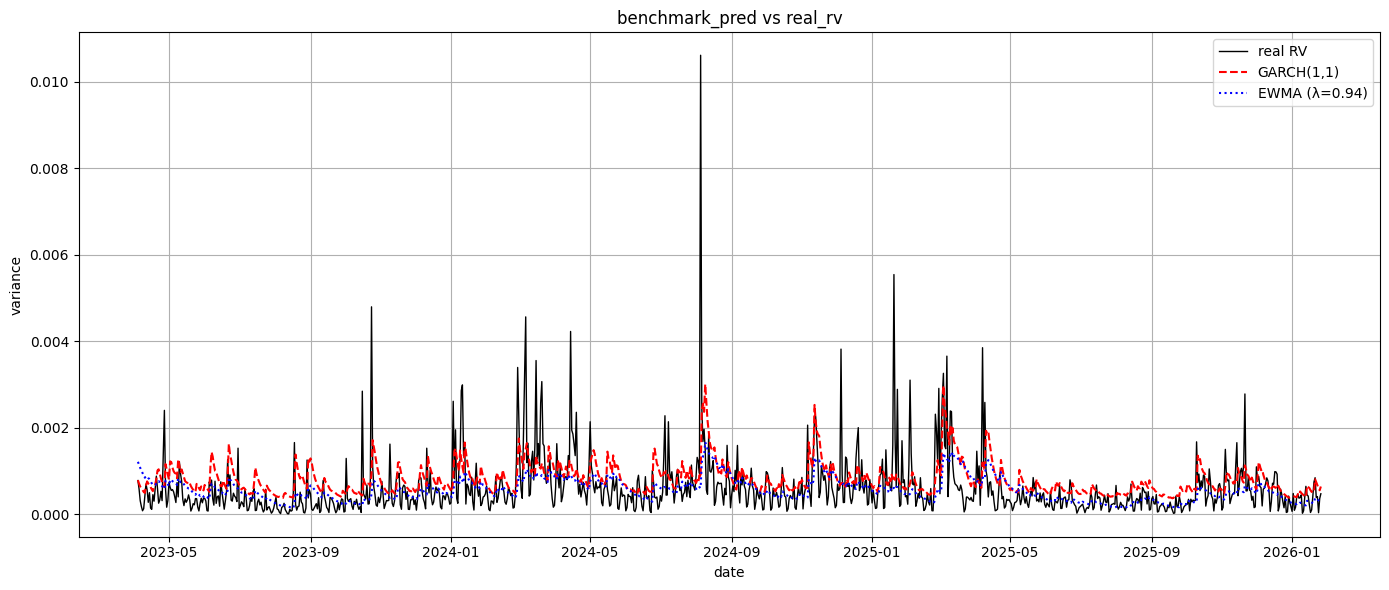

In [9]:
#可视化对比
plt.figure(figsize=(14,6))
plt.plot(true_rv.index, true_rv, label='real RV', color='black', linewidth=1)
plt.plot(garch_pred_aligned.index, garch_pred_aligned, label='GARCH(1,1)', color='red', linestyle='--')
plt.plot(ewma_pred.index, ewma_pred, label='EWMA (λ=0.94)', color='blue', linestyle=':')
plt.legend()
plt.title('benchmark_pred vs real_rv')
plt.xlabel('date')
plt.ylabel('variance')
plt.grid(True)
plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150)
plt.show()

In [10]:
results = pd.DataFrame({
    'date': true_rv.index,
    'true_rv': true_rv.values,
    'garch_pred': garch_pred_aligned.values,
    'ewma_pred': ewma_pred.values
})
results.to_csv('../data/benchmark_predictions.csv', index=False)